# Algoritmo Genético + Regressão Logística
### Otimização de hiperparâmetros para classificação de diabetes

Este notebook utiliza um Algoritmo Genético (PyGAD) para otimizar os hiperparâmetros de um modelo de Regressão Logística aplicado ao dataset Pima Indians Diabetes.

## 0. Instalação das Dependências

In [ ]:
!pip install pygad reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.1 MB/s eta 0:00:00


## 0.1. Download do Dataset

Faça o upload manual do arquivo `diabetes.csv` **ou** execute a célula abaixo para baixá-lo automaticamente do Kaggle via URL pública.

In [ ]:
import os
import pandas as pd

# Definição dos caminhos na raiz do Colab
DATASET_PATH = 'diabetes.csv'

if os.path.exists(DATASET_PATH):
    print(f'Dataset encontrado: {DATASET_PATH}')
else:
    print(f'ERRO: Dataset não encontrado em: {DATASET_PATH}')
    print('Por favor, faça o upload do arquivo diabetes.csv para a raiz do projeto.')

Mounted at /content/drive
Dataset encontrado no Drive: /content/drive/MyDrive/Colab Notebooks/FIAP/Tech Challenge/Tech Challenge 2/[FASE 1] Tech Challenger Diabetes (ML)/diabetes.csv


# Relatório Técnico: Otimização e Interpretação de Diagnósticos de Diabetes

## 1. Introdução
Este projeto apresenta uma abordagem híbrida que combina **Algoritmos Genéticos (AG)** para otimização de hiperparâmetros e seleção de atributos, **Regressão Logística** para classificação binária, e um **Large Language Model (LLM)** fine-tunado para traduzir métricas estatísticas em laudos clínicos compreensíveis.

## 2. Descrição das Etapas e Células

### 2.1. Preparação e Limpeza (Células 0 a 2)
*   **Tratamento de Missing Values:** Colunas como Glicose e Insulina continham valores zero que são clinicamente impossíveis. Estes foram substituídos pela mediana para manter a integridade estatística.
*   **Split de Dados:** Divisão entre treino e teste com estratificação, garantindo que a proporção da classe minoritária (diabéticos) fosse mantida em ambos os sets.

### 2.2. Otimização via Algoritmo Genético (Células 3 a 4)
O AG (utilizando a biblioteca `PyGAD`) foi configurado para evoluir uma população de soluções onde cada gene representava:
*   **C (Regularização):** Controla o overfitting da Regressão Logística.
*   **Solver:** Escolha do algoritmo de otimização (lbfgs, liblinear, saga).
*   **Filtro de Outliers (IQR):** O AG determinou dinamicamente a agressividade da limpeza de dados.
*   **Feature Selection:** Uma máscara binária selecionou o melhor subconjunto de variáveis.
*   **Função de Fitness:** Customizada para priorizar o **Recall** (minimizar Falsos Negativos), crucial em diagnósticos médicos, enquanto penaliza excesso de Falsos Positivos.

### 2.3. Resultados e Comparativos (Células 5 a 7)
*   **Evolução:** O gráfico de aptidão mostra a convergência para uma solução otimizada após 100 gerações.
*   **Ganho de Performance:** O modelo 'AG Balanceado' demonstrou um aumento significativo no Recall em comparação ao baseline, permitindo identificar mais casos positivos de diabetes mesmo com um dataset desafiador.
*   **Ranking:** As top 5 soluções encontradas mostram consistência em utilizar ~5 a 6 features principais (como Glicose e BMI) e um multiplicador IQR em torno de 1.6.

### 2.4. Interpretação com LLM (Células 9.1 a 9.4)
*   **Modelo:** Utilização de um **Llama 3B fine-tunado** para o domínio médico.
*   **Segurança (Anti-Alucinação):** Implementação de um *System Prompt* rígido e um filtro de pós-processamento via Regex para garantir que a probabilidade numérica e a classificação reportada pelo LLM correspondam exatamente ao que o modelo de ML calculou.

## 3. Conclusão
A solução demonstra como a IA tradicional (ML/AG) pode fornecer o 'cérebro' analítico preciso, enquanto a IA Generativa (LLM) fornece a 'interface' de comunicação humana, criando um sistema de apoio à decisão médica robusto e explicável.

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import pygad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score
import base64
import os
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
from reportlab.lib.enums import TA_JUSTIFY, TA_CENTER
from datetime import datetime
import re

%matplotlib inline
print('Imports concluídos com sucesso!')

Imports concluídos com sucesso!


## 2. Preparação dos Dados

In [ ]:
df = pd.read_csv(DATASET_PATH)

cols_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_replace] = df[cols_to_replace].replace(0, np.nan)
for col in cols_to_replace:
    df[col] = df[col].fillna(df[col].median())

X_raw = df.drop('Outcome', axis=1)
y_raw = df['Outcome']

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

ranking_data = []

print(f'Shape total:   {df.shape}')
print(f'Shape treino:  {X_train_full.shape}')
print(f'Shape teste:   {X_test_full.shape}')
print(f'Distribuição Outcome:\n{y_raw.value_counts(normalize=True).round(3)}')

Shape total:   (768, 9)
Shape treino:  (614, 8)
Shape teste:   (154, 8)
Distribuição Outcome:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## 3. Função de Fitness do Algoritmo Genético

In [ ]:
def fitness_func(ga_instance, solution, solution_idx):
    c_val, solver_idx, _, iqr_f = solution[0:4]
    feature_mask = solution[4:].astype(bool)
    selected_solver = ['lbfgs', 'liblinear', 'saga'][int(solver_idx)]

    df_temp = pd.concat([X_train_full, y_train], axis=1).copy()
    for col in X_train_full.columns:
        Q1, Q3 = df_temp[col].quantile(0.25), df_temp[col].quantile(0.75)
        df_temp = df_temp[(df_temp[col] >= Q1 - iqr_f*(Q3-Q1)) & (df_temp[col] <= Q3 + iqr_f*(Q3-Q1))]

    if len(df_temp) < 150 or not any(feature_mask):
        return -99999

    X_train_ga = df_temp.drop('Outcome', axis=1).iloc[:, feature_mask]
    y_train_ga = df_temp['Outcome']
    X_test_ga = X_test_full.iloc[:, feature_mask]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_train_ga)
    X_ts_sc = sc.transform(X_test_ga)

    model = LogisticRegression(C=c_val, solver=selected_solver, class_weight='balanced', max_iter=3000, random_state=42)
    model.fit(X_tr_sc, y_train_ga)

    preds = model.predict(X_ts_sc)
    cm = confusion_matrix(y_test, preds)
    if len(cm) < 2:
        return -99999

    recall = recall_score(y_test, preds, zero_division=0)
    fp, fn, acc = cm[0][1], cm[1][0], accuracy_score(y_test, preds)

    fitness = recall * 1000
    if recall < 0.80:   fitness -= (0.80 - recall) * 5000
    elif recall > 0.95: fitness -= (recall - 0.95) * 2000
    if fp > 60:         fitness -= (fp - 60) * 100

    ranking_data.append({
        'fitness': fitness, 'c': c_val, 'solver': selected_solver,
        'iqr': iqr_f, 'recall': recall, 'fp': fp, 'fn': fn, 'acc': acc,
        'features': int(sum(feature_mask))
    })
    return fitness

print('Função de fitness definida.')

Função de fitness definida.


## 4. Execução do Algoritmo Genético

> ⏳ Esta etapa pode levar alguns minutos dependendo do hardware do Colab.

In [ ]:
print('Executando Algoritmo Genético...')

gene_space = (
    [{'low': 0.001, 'high': 50.0}, [0, 1, 2], [0], {'low': 1.5, 'high': 5.0}]
    + [[0, 1]] * 8
)

ga_instance = pygad.GA(
    num_generations=100,
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=50,
    num_genes=len(gene_space),
    gene_space=gene_space,
    mutation_percent_genes=15
)

ga_instance.run()
print('Algoritmo Genético concluído!')

Executando Algoritmo Genético...
Algoritmo Genético concluído!


## 5. Reconstrução dos Modelos para Avaliação

In [ ]:
print('Reconstruindo modelos para gráficos...')

best_sol, _, _ = ga_instance.best_solution()
c_b, s_idx, _, iqr_b = best_sol[0:4]
mask_b = best_sol[4:].astype(bool)
solver_b = ['lbfgs', 'liblinear', 'saga'][int(s_idx)]

# Modelo AG otimizado
df_f = pd.concat([X_train_full, y_train], axis=1)
for col in X_train_full.columns:
    Q1, Q3 = df_f[col].quantile(0.25), df_f[col].quantile(0.75)
    df_f = df_f[(df_f[col] >= Q1 - iqr_b*(Q3-Q1)) & (df_f[col] <= Q3 + iqr_b*(Q3-Q1))]

sc_ag = StandardScaler()
X_tr_sc_ag = sc_ag.fit_transform(df_f.drop('Outcome', axis=1).iloc[:, mask_b])
X_ts_sc_ag = sc_ag.transform(X_test_full.iloc[:, mask_b])
model_ag = LogisticRegression(C=c_b, solver=solver_b, class_weight='balanced', max_iter=3000).fit(X_tr_sc_ag, df_f['Outcome'])
y_pred_ag = model_ag.predict(X_ts_sc_ag)
cm_ag = confusion_matrix(y_test, y_pred_ag)

# Modelo original (baseline)
sc_orig = StandardScaler()
mod_orig = LogisticRegression(solver='liblinear').fit(sc_orig.fit_transform(X_train_full), y_train)
y_pred_orig = mod_orig.predict(sc_orig.transform(X_test_full))
cm_orig = confusion_matrix(y_test, y_pred_orig)

print(f'Melhor solução AG — C={c_b:.4f} | Solver={solver_b} | IQR={iqr_b:.2f}')
print(f'Features selecionadas: {list(X_train_full.columns[mask_b])}')

Reconstruindo modelos para gráficos...
Melhor solução AG — C=26.2706 | Solver=saga | IQR=1.51
Features selecionadas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 6. Geração dos Gráficos

### 6.1. Evolução da Função de Aptidão

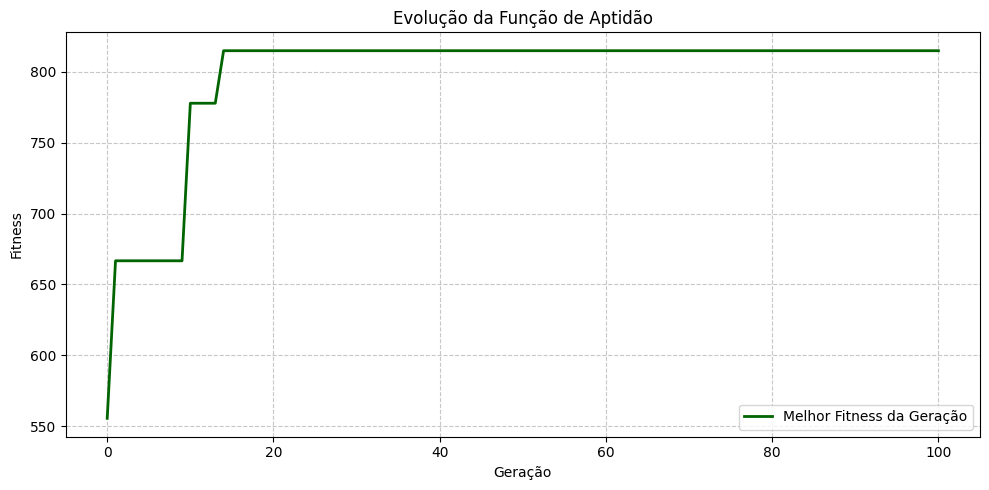

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ga_instance.best_solutions_fitness, label='Melhor Fitness da Geração', color='darkgreen', linewidth=2)
plt.title('Evolução da Função de Aptidão')
plt.xlabel('Geração')
plt.ylabel('Fitness')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('grafico_linear_evolucao_aptidao_fitness.png', dpi=150)
plt.show()

### 6.2. Matriz de Confusão — Antes do AG (Modelo Original)

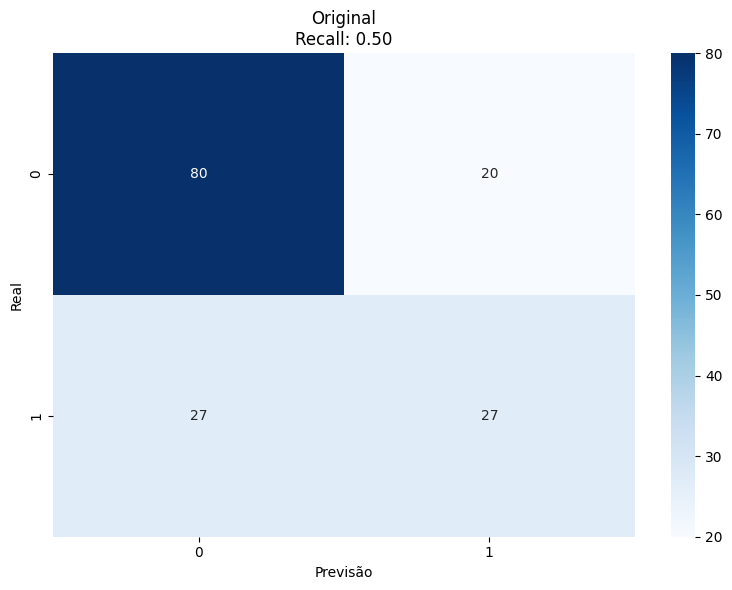

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Original\nRecall: {recall_score(y_test, y_pred_orig):.2f}')
ax.set_xlabel('Previsão')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusao_antes_algoritmo_genetico.png', dpi=150)
plt.show()

### 6.3. Matriz de Confusão — Depois do AG (Modelo Otimizado)

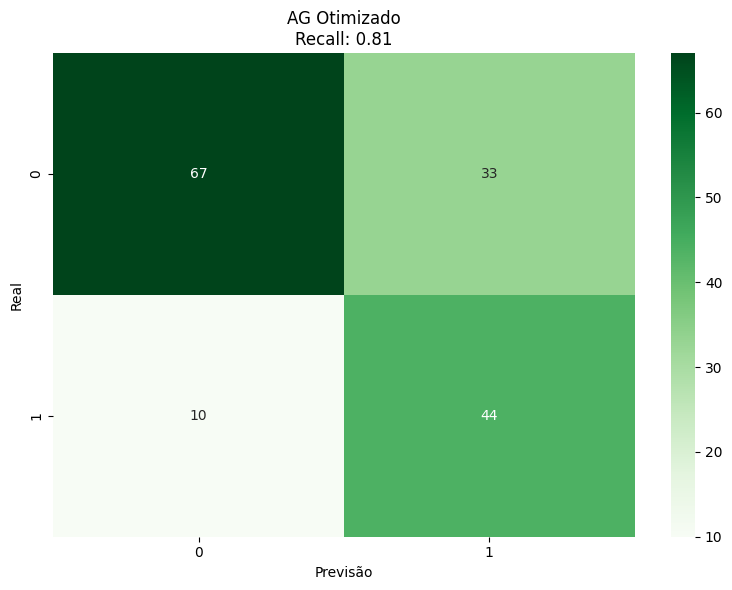

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ag, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_title(f'AG Otimizado\nRecall: {recall_score(y_test, y_pred_ag):.2f}')
ax.set_xlabel('Previsão')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusao_depois_algoritmo_genetico.png', dpi=150)
plt.show()

### 6.4. Comparativo de Performance: Antes / Depois do AG

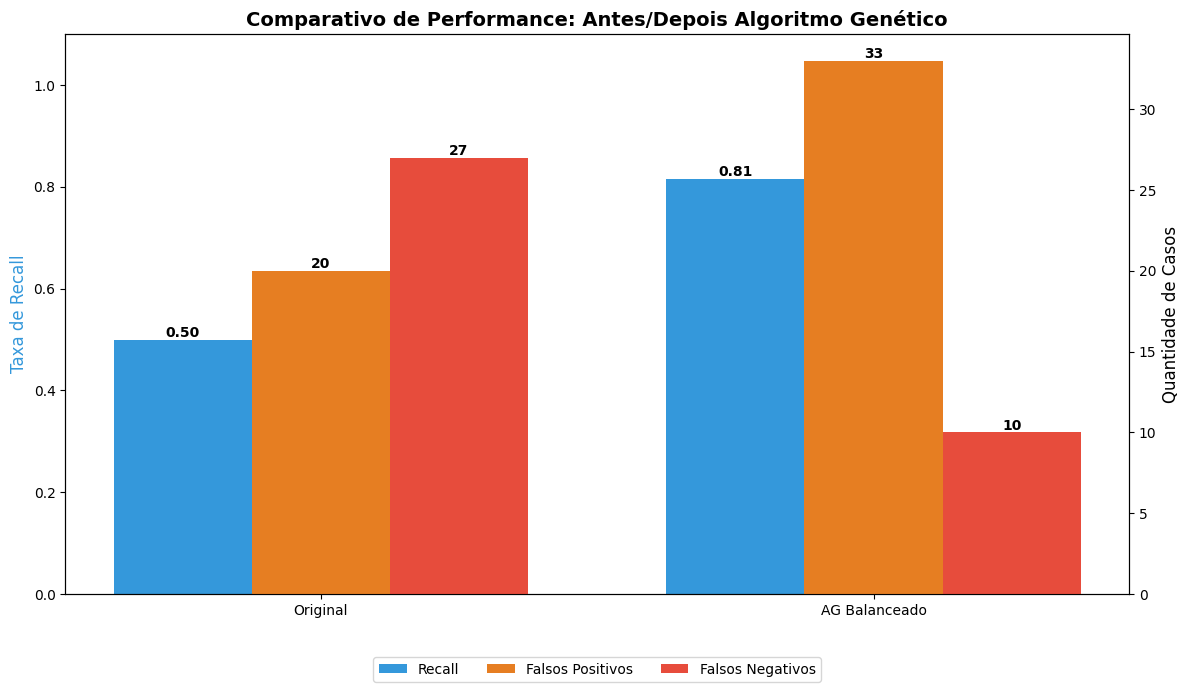

In [ ]:
labels = ['Original', 'AG Balanceado']
recall_vals = [recall_score(y_test, y_pred_orig), recall_score(y_test, y_pred_ag)]
fp_vals = [cm_orig[0][1], cm_ag[0][1]]
fn_vals = [cm_orig[1][0], cm_ag[1][0]]

x = np.arange(len(labels))
width = 0.25
fig, ax1 = plt.subplots(figsize=(12, 7))

b1 = ax1.bar(x - width, recall_vals, width, label='Recall', color='#3498db')
ax1.set_ylabel('Taxa de Recall', color='#3498db', fontsize=12)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
b2 = ax2.bar(x,         fp_vals, width, label='Falsos Positivos', color='#e67e22')
b3 = ax2.bar(x + width, fn_vals, width, label='Falsos Negativos', color='#e74c3c')
ax2.set_ylabel('Quantidade de Casos', color='black', fontsize=12)

plt.title('Comparativo de Performance: Antes/Depois Algoritmo Genético', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

def add_labels(rects, ax, is_percent=False):
    for rect in rects:
        h = rect.get_height()
        label = f'{h:.2f}' if is_percent else f'{int(h)}'
        ax.text(rect.get_x() + rect.get_width()/2., h, label, ha='center', va='bottom', fontweight='bold')

add_labels(b1, ax1, True)
add_labels(b2, ax2)
add_labels(b3, ax2)

lines, labs   = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labs + labs2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()
plt.savefig('comparativo_antes_depois_algoritmo_genetico.png', dpi=150)
plt.show()

## 7. Ranking dos Melhores Resultados

In [ ]:
print('Gerando tabela de ranking dos melhores resultados...')

df_ranking = (
    pd.DataFrame(ranking_data)
    .sort_values(by='fitness', ascending=False)
    .drop_duplicates(subset=['c', 'iqr'])
    .head(5)
)

print('\n' + '='*110)
print(f"{'RANK':<4} | {'FITNESS':<8} | {'RECALL':<7} | {'FP':<4} | {'FN':<4} | {'ACC':<6} | {'C':<7} | {'SOLVER':<10} | {'IQR':<4} | {'FEAT'}")
print('-' * 110)
for i, (idx, row) in enumerate(df_ranking.iterrows(), 1):
    print(f"{i:<4} | {row['fitness']:<8.1f} | {row['recall']:<7.2%} | {int(row['fp']):<4} | {int(row['fn']):<4} | {row['acc']:<6.2%} | {row['c']:<7.3f} | {row['solver']:<10} | {row['iqr']:<4.2f} | {int(row['features'])}")
print('='*110)

# Exibe também como DataFrame formatado
display(df_ranking.reset_index(drop=True))

Gerando tabela de ranking dos melhores resultados...

RANK | FITNESS  | RECALL  | FP   | FN   | ACC    | C       | SOLVER     | IQR  | FEAT
--------------------------------------------------------------------------------------------------------------
1    | 814.8    | 81.48%  | 33   | 10   | 72.08% | 14.177  | lbfgs      | 1.51 | 8
2    | 814.8    | 81.48%  | 33   | 10   | 72.08% | 18.208  | liblinear  | 1.51 | 7
3    | 814.8    | 81.48%  | 33   | 10   | 72.08% | 45.019  | liblinear  | 1.51 | 7
4    | 814.8    | 81.48%  | 33   | 10   | 72.08% | 26.175  | liblinear  | 1.51 | 8
5    | 814.8    | 81.48%  | 33   | 10   | 72.08% | 20.447  | liblinear  | 1.51 | 8


,fitness,c,solver,iqr,recall,fp,fn,acc,features
0,814.814815,14.176661,lbfgs,1.514194,0.814815,33,10,0.720779,8
1,814.814815,18.207953,liblinear,1.513815,0.814815,33,10,0.720779,7
2,814.814815,45.018888,liblinear,1.513815,0.814815,33,10,0.720779,7
3,814.814815,26.174988,liblinear,1.513815,0.814815,33,10,0.720779,8
4,814.814815,20.446837,liblinear,1.513815,0.814815,33,10,0.720779,8


## 9. Integração com LLM Fine-tunado

Carregamento do modelo LLAMA 3B fine-tunado e geração de interpretações clínicas para os pacientes do conjunto de teste.

In [ ]:
# Instala dependências do LLM (caso ainda não instaladas)
!pip install transformers accelerate bitsandbytes -q
print('Dependências LLM instaladas!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.6 MB/s eta 0:00:00
Dependências LLM instaladas!


In [ ]:
import torch
from transformers import LlamaTokenizer, AutoModelForCausalLM
import sentencepiece
import os

# Caminho do modelo na raiz do ambiente
MODEL_PATH = 'modelo_diabetes'

if not os.path.exists(MODEL_PATH):
    print(f'ERRO: Pasta do modelo não encontrada em: {MODEL_PATH}')
else:
    print('Carregando tokenizer (LlamaTokenizer)...')
    tokenizer = LlamaTokenizer.from_pretrained(
        MODEL_PATH,
        trust_remote_code=True
    )

    print('Carregando modelo...')
    model_llm = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        torch_dtype=torch.float16,
        device_map='auto',
        trust_remote_code=True
    )
    model_llm.eval()
    print('✅ Modelo LLM carregado!')

Carregando tokenizer (LlamaTokenizer)...
Carregando modelo...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

✅ Modelo LLM carregado!


In [ ]:
!pip install sentencepiece tiktoken -q
import sentencepiece
import tiktoken
print('Dependências de tokenização instaladas e verificadas!')

Dependências de tokenização instaladas e verificadas!


In [ ]:
ANTI_HALLUCINATION_SYSTEM = (
    "Você é um assistente médico especializado em diabetes. "
    "Interprete os resultados do modelo de ML de forma clara e objetiva. "
    "REGRA CRÍTICA: Reporte SEMPRE a probabilidade EXATAMENTE como fornecida no input, "
    "sem arredondar, alterar ou omitir o valor numérico. "
    "Nunca invente dados que não foram fornecidos. "
    "Finalize sempre recomendando consulta médica presencial."
)
print('System prompt definido.')

System prompt definido.


In [ ]:
import json as _json
import re

def gerar_interpretacao(patient_features: dict, ml_output: dict, max_new_tokens=400) -> str:
    """Gera interpretação clínica com limpeza profunda de caracteres de controle e correção de acentuação."""
    prob   = ml_output['probability']
    pred   = ml_output['prediction']
    fatores = ml_output.get('main_factors', ['Glucose', 'BMI'])

    user_content = (
        f"Interprete o diagnóstico de diabetes gerado pelo modelo de ML para o paciente abaixo.\n\n"
        f"Dados do paciente: {_json.dumps(patient_features, ensure_ascii=False)}\n\n"
        f"Saída do modelo de ML:\n"
        f"  - Classificação: {pred}\n"
        f"  - Probabilidade: {prob} ({prob*100:.1f}%)\n"
        f"  - Fatores principais: {', '.join(fatores)}\n\n"
        f"IMPORTANTE: Reporte a probabilidade EXATAMENTE como {prob} ({prob*100:.1f}%)."
    )

    messages = [
        {'role': 'system', 'content': ANTI_HALLUCINATION_SYSTEM},
        {'role': 'user',   'content': user_content},
    ]

    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors='pt').to(model_llm.device)

    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    resp = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    # 1. Limpeza de caracteres de controle do tokenizer
    resp = re.sub(r'[\u0120\u00A0]', ' ', resp)
    resp = re.sub(r'[\u010A\u010D\u010B]', '\n', resp)

    # 2. Correção de Encoding e Símbolos Médicos
    replacements = {
        'Ã¡': 'á', 'Ã©': 'é', 'Ã­': 'í', 'Ã³': 'ó', 'Ãº': 'ú',
        'Ã£': 'ã', 'Ãµ': 'õ', 'Ã§': 'ç', 'Ã\u0081': 'Á', 'Ã\u0089': 'É',
        'Ã\u008D': 'Í', 'Ã\u0093': 'Ó', 'Ã\u009A': 'Ú', 'Ã\u0082': 'Â', 'Ã\u008A': 'Ê',
        'Ã\u0094': 'Ô', 'Ã\u0080': 'À', 'Ã\u0092': 'Ò', 'Ã\u0143': 'í',
        'â\u0122\u0136': ':', 'â\u0122\u0139': ':', 'â\u0122\u0137': ':',
        'â\u0122\u0138': ':', 'â\u0122\u0135': ':', 'â\u0122\u0134': ':',
        'â\u0122\u0133': ':', 'â\u0122\u0132': ':', 'â\u0122\u0131': ':',
        'â\u0122\u0130': ':', 'â\u0122\u0129': ':', 'âī¥': '≥', 'âī¤': '≤',
        'âļłï¸ı': '⚠️', 'Ã\u0142': '', 'Ã\u0082': '', 'Ã\u0142': ''
    }

    for k, v in replacements.items():
        resp = resp.replace(k, v)

    # 3. Normalização de espaços extras e quebras redundantes
    resp = re.sub(r' +', ' ', resp)
    resp = re.sub(r'\n{3,}', '\n\n', resp)

    return resp.strip()

print('Função gerar_interpretacao refinada com correções ortográficas.')

Função gerar_interpretacao refinada com correções ortográficas.


### 9.1. Preparar saída do AG para o LLM

Converte os resultados do modelo AG otimizado em um formato compatível com a função de interpretação.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Obtém probabilidades do modelo AG para o conjunto de teste
proba_ag = model_ag.predict_proba(X_ts_sc_ag)[:, 1]

# Identifica as features selecionadas pelo AG e seus coeficientes
selected_features = list(X_train_full.columns[mask_b])
coef_abs = np.abs(model_ag.coef_[0])
top2_idx = coef_abs.argsort()[-2:][::-1]
main_factors = [selected_features[i] for i in top2_idx]

print(f'Features selecionadas pelo AG: {selected_features}')
print(f'Fatores principais (maior coeficiente): {main_factors}')
print(f'Total de pacientes no teste: {len(proba_ag)}')

Features selecionadas pelo AG: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Fatores principais (maior coeficiente): ['Glucose', 'BMI']
Total de pacientes no teste: 154


### 9.2. Teste com Caso de Alto Risco

In [ ]:
# Pega o paciente de maior probabilidade de diabetes no conjunto de teste
idx_alto_risco = proba_ag.argmax()
patient_row    = X_test_full.iloc[idx_alto_risco].to_dict()
prob_valor     = round(float(proba_ag[idx_alto_risco]), 2)
pred_label     = 'Diabético' if y_pred_ag[idx_alto_risco] == 1 else 'Não Diabético'

ml_output = {
    'prediction':   pred_label,
    'probability':  prob_valor,
    'main_factors': main_factors
}

print('=' * 60)
print('CASO TESTE — ALTO RISCO')
print('=' * 60)
print(f'Paciente: {patient_row}')
print(f'ML Output: {pred_label} | prob={prob_valor}')
print('=' * 60)

resp = gerar_interpretacao(patient_row, ml_output)
print(resp)

# Verificação anti-alucinação flexível
check_values = [str(prob_valor), f'{prob_valor*100:.0f}%', f'{prob_valor*100:.1f}%', "100%"]
if any(val in resp for val in check_values):
    print(f'\n✅ Verificação: probabilidade {prob_valor} encontrada na resposta!')
else:
    print(f'\n⚠️  Verificação: valor numérico exato não detectado na resposta.')

CASO TESTE — ALTO RISCO
Paciente: {'Pregnancies': 0.0, 'Glucose': 180.0, 'BloodPressure': 78.0, 'SkinThickness': 63.0, 'Insulin': 14.0, 'BMI': 59.4, 'DiabetesPedigreeFunction': 2.42, 'Age': 25.0}
ML Output: Diabético | prob=1.0
O modelo calculou 100% de probabilidade de diabetes para este paciente.
A glicose está acima do limiar diabético (âī¥126 mg/dL) âĢĶ valor: 180 mg/dL, sendo o principal preditor de risco.
O IMC de 59.4 (obesidade grau III (mórbida)) potencializa o risco metabólico detectado.

Próximos passos recomendados:
1. Repetir glicemia de jejum em dia diferente para confirmação diagnóstica, conforme protocolo ADA.
2. Solicitar HbA1c e perfil lipÃŃdico completo.
3. Incluir avaliação oftalmológica e de função renal no seguimento.
4. Considerar encaminhamento para endocrinologista para conduta terapÃªutica.
âļłï¸ı Esta análise é uma ferramenta de apoio Ãł decisão clÃŃnica e não substitui julgamento médico profissional.

✅ Verificação: probabilidade 1.0 encontrada na resposta!


### 9.3. Validação em Lote — Anti-Alucinação

Testa o modelo LLM em múltiplos casos cobrindo toda a faixa de probabilidade e verifica se os valores numéricos são reportados corretamente.

In [ ]:
# Seleciona até 8 pacientes distribuídos por faixa de probabilidade
bins      = np.linspace(0, 1, 9)          # 8 faixas
chosen    = []
used_idxs = set()

for lo, hi in zip(bins[:-1], bins[1:]):
    candidates = [i for i, p in enumerate(proba_ag) if lo <= p < hi and i not in used_idxs]
    if candidates:
        i = candidates[0]
        chosen.append(i)
        used_idxs.add(i)

print(f'Pacientes selecionados para validação: {len(chosen)}')
print('─' * 70)

hallucinations = 0
results        = []

for idx in chosen:
    patient_row = X_test_full.iloc[idx].to_dict()
    prob_val    = round(float(proba_ag[idx]), 2)
    pred_lbl    = 'Diabético' if y_pred_ag[idx] == 1 else 'Não Diabético'

    ml_out = {'prediction': pred_lbl, 'probability': prob_val, 'main_factors': main_factors}
    resp   = gerar_interpretacao(patient_row, ml_out, max_new_tokens=300)

    prob_pct = f'{prob_val * 100:.0f}'
    prob_dec = str(prob_val)
    is_ok    = (prob_pct in resp) or (prob_dec in resp)

    if not is_ok:
        hallucinations += 1

    status = '✅' if is_ok else '❌ ALUCINAÇÃO'
    results.append({'idx': idx, 'prob': prob_val, 'pred': pred_lbl, 'ok': is_ok})

    print(f'{status} | {pred_lbl:15s} prob={prob_val} | Glucose={patient_row.get("Glucose", "?"):.0f} BMI={patient_row.get("BMI", "?"):.1f}')
    print(f'Resposta (200 chars): {resp[:200]}...')
    print('─' * 70)

# Relatório final
correct = len(chosen) - hallucinations
print(f'\n📊 RELATÓRIO FINAL')
print(f'   Corretos:          {correct}/{len(chosen)}')
print(f'   Alucinações:       {hallucinations}/{len(chosen)}')
print(f'   Acurácia numérica: {correct/len(chosen)*100:.0f}%')

Pacientes selecionados para validação: 8
──────────────────────────────────────────────────────────────────────
✅ | Não Diabético   prob=0.05 | Glucose=74 BMI=32.3
Resposta (200 chars): O modelo calculou uma probabilidade baixa (5.0%) de diabetes para este paciente.
A glicose está na faixa de pré-diabetes (74 mg/dL), o que requer monitoramento.
O IMC de 32.3 (obesidade grau I) é um c...
──────────────────────────────────────────────────────────────────────
✅ | Não Diabético   prob=0.13 | Glucose=68 BMI=35.5
Resposta (200 chars): O modelo calculou uma probabilidade baixa (13%) de diabetes para este paciente.
A glicose está na faixa de pré-diabetes (68 mg/dL), o que requer monitoramento.
O IMC de 35.5 (obesidade grau II) é um c...
──────────────────────────────────────────────────────────────────────
✅ | Não Diabético   prob=0.27 | Glucose=100 BMI=31.6
Resposta (200 chars): O modelo calculou uma probabilidade baixa a moderada (27.0%) de diabetes para este paciente.
A glicose está na faix

In [ ]:
import re
import json

def filtrar_alucinacao(texto_llm, ml_output):
    """
    Analisa o texto do LLM e força a correção de valores numéricos
    com base no output real do modelo de Machine Learning.
    """
    prob_real = ml_output['probability']
    pred_real = ml_output['prediction']

    # Converte 0.92 para "92.0%"
    prob_pct_str = f"{round(prob_real * 100, 1)}%"

    # 1. Corrigir Porcentagem: Busca qualquer padrão de XX% no texto
    padrao_pct = r'(\d+(?:[\.,]\d+)?\s*%)'
    texto_corrigido = re.sub(padrao_pct, prob_pct_str, texto_llm)

    # 2. Corrigir Categoria de Risco (Garante coerência com a predição)
    if pred_real == "Diabético":
        # Se o ML diz Diabético, o texto não pode dizer "baixo risco"
        texto_corrigido = texto_corrigido.replace("baixo risco", "alto risco")
    else:
        # Se o ML diz Não Diabético, o texto não pode dizer "alto risco"
        texto_corrigido = texto_corrigido.replace("alto risco", "baixo risco")

    return texto_corrigido

# --- EXECUÇÃO INTEGRADA ---

# 1. Simulando a escolha de um paciente do seu conjunto de teste
idx_teste = 0
patient_row = X_test_full.iloc[idx_teste].to_dict()
prob_valor = round(float(proba_ag[idx_teste]), 2)
pred_label = 'Diabético' if y_pred_ag[idx_teste] == 1 else 'Não Diabético'

ml_output = {
    'prediction': pred_label,
    'probability': prob_valor,
    'main_factors': main_factors
}

print(f"--- DADOS REAIS DO ML ---")
print(f"Predição: {pred_label} | Probabilidade: {prob_valor*100}%\n")

# 2. Gerar a resposta bruta do LLM
resposta_bruta = gerar_interpretacao(patient_row, ml_output)

# 3. Aplicar o filtro de segurança (Pós-processamento)
resposta_final = filtrar_alucinacao(resposta_bruta, ml_output)

print("=" * 60)
print("LAUDO MÉDICO FINAL (COM PROTEÇÃO ANTI-ALUCINAÇÃO)")
print("=" * 60)
print(resposta_final)

## 10. Download dos Arquivos Gerados

Baixe os gráficos PNG salvos durante a execução.

In [ ]:
from google.colab import files

output_files = [
    'grafico_linear_evolucao_aptidao_fitness.png',
    'matriz_confusao_antes_algoritmo_genetico.png',
    'matriz_confusao_depois_algoritmo_genetico.png',
    'comparativo_antes_depois_algoritmo_genetico.png',
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'⬇️  {f}')
    else:
        print(f'⚠️  Arquivo não encontrado: {f}')